In [1]:
# ============================================================
# CLASSIFICATION MODEL - DATA PREPARATION
# ============================================================

print("="*70)
print("CLASSIFICATION MODEL: PREDICTING AI ATTRACTION")
print("="*70)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('final_cleaned_content_dataset.csv')
print(f"✅ Loaded: {df.shape[0]:,} rows, {df.shape[1]} columns")

# Check target distribution
print("\n📊 Target Distribution (AI Attraction):")
print("-"*40)
ai_counts = df['has_ai'].value_counts()
print(f"  No AI Traffic (0): {ai_counts[0]:,} ({ai_counts[0]/len(df)*100:.1f}%)")
print(f"  Has AI Traffic (1): {ai_counts[1]:,} ({ai_counts[1]/len(df)*100:.1f}%)")

# Check for class imbalance
print(f"\n⚠️ Class Imbalance Ratio: {ai_counts[1]/ai_counts[0]:.4f}")

CLASSIFICATION MODEL: PREDICTING AI ATTRACTION
✅ Loaded: 328,450 rows, 31 columns

📊 Target Distribution (AI Attraction):
----------------------------------------
  No AI Traffic (0): 326,273 (99.3%)
  Has AI Traffic (1): 2,177 (0.7%)

⚠️ Class Imbalance Ratio: 0.0067


### Observations & Insights (CLASSIFICATION MODEL - DATA PREPARATION)

*   **Dataset Size:** The dataset `df` contains `328,450` rows and `31` columns, indicating a substantial amount of data for analysis.
*   **Target Variable (`has_ai`) Distribution:**
    *   `No AI Traffic (0)` accounts for `326,273` records (`99.3%`).
    *   `Has AI Traffic (1)` accounts for only `2,177` records (`0.7%`).
*   **Class Imbalance:** There is a severe class imbalance with a ratio of `0.0067`, meaning there are approximately 150 times more negative samples than positive samples. This is a critical observation, as models trained on such imbalanced data often struggle to predict the minority class (`Has AI Traffic`).

**Recommendation:** Address the class imbalance during model training (e.g., using `class_weight`, oversampling, or undersampling techniques) to ensure the model can effectively learn to identify the minority class.

In [2]:
# ============================================================
# FEATURE SELECTION FOR CLASSIFICATION
# ============================================================

print("="*70)
print("FEATURE SELECTION")
print("="*70)

# Features for classification (NO target-derived features)
feature_cols = [
    # Search signals (NO clicks, NO CTR)
    'total_impressions',
    'avg_position',

    # Engagement signals
    'total_pageviews',
    'total_engagement_sec',
    'total_scrolls',
    'scrolls_per_view',

    # Traffic signals (EXCLUDING referral_sessions)
    'organic_sessions',
    'direct_sessions',
    'social_sessions',

    # Content signals
    'active_days'
]

# Filter to existing columns
existing_features = [col for col in feature_cols if col in df.columns]
print(f"✅ Features: {len(existing_features)}")

# Create feature matrix
X_clf = df[existing_features].copy()

# Handle infinite values and zeros
X_clf = X_clf.replace([np.inf, -np.inf], 0)
X_clf = X_clf.fillna(0)

print(f"✅ Feature matrix shape: {X_clf.shape}")

# Log transform skewed features
print("\n📊 Log transforming skewed features:")
for col in ['total_impressions', 'total_pageviews', 'organic_sessions', 'total_scrolls']:
    if col in X_clf.columns:
        if (X_clf[col] > 0).any():
            X_clf[f'{col}_log'] = np.log1p(X_clf[col])
            X_clf = X_clf.drop(columns=[col])
            print(f"  ✅ Log transformed: {col}")

print(f"\n✅ Final feature matrix: {X_clf.shape}")
print(f"✅ Features: {X_clf.columns.tolist()}")

FEATURE SELECTION
✅ Features: 10
✅ Feature matrix shape: (328450, 10)

📊 Log transforming skewed features:
  ✅ Log transformed: total_impressions
  ✅ Log transformed: total_pageviews
  ✅ Log transformed: organic_sessions
  ✅ Log transformed: total_scrolls

✅ Final feature matrix: (328450, 10)
✅ Features: ['avg_position', 'total_engagement_sec', 'scrolls_per_view', 'direct_sessions', 'social_sessions', 'active_days', 'total_impressions_log', 'total_pageviews_log', 'organic_sessions_log', 'total_scrolls_log']


### Observations & Insights (FEATURE SELECTION)

*   **Feature Set:** A set of 10 initial features was selected, covering search signals, engagement signals, traffic signals, and content signals. This is a good starting point for predicting AI attraction.
*   **Log Transformation:** Several features (`total_impressions`, `total_pageviews`, `organic_sessions`, `total_scrolls`) were log-transformed. This is a common and effective technique for features that exhibit highly skewed distributions, which can help models perform better by normalizing the scale and reducing the impact of outliers.
*   **Final Feature Matrix:** The final feature matrix `X_clf` maintains the original number of rows (`328,450`) but now has 10 columns, with the original skewed features replaced by their log-transformed counterparts.

**Recommendation:** The feature selection and transformation steps appear sound. It's good practice to ensure that the log transformation was necessary by inspecting the distributions before and after, but given the typical nature of these metrics, it's a reasonable assumption.

In [3]:
# ============================================================
# TRAIN/TEST SPLIT
# ============================================================

print("="*70)
print("TRAIN/TEST SPLIT")
print("="*70)

# Target variable
y_clf = df.loc[X_clf.index, 'has_ai']

# Scale features
scaler_clf = StandardScaler()
X_clf_scaled = scaler_clf.fit_transform(X_clf)

# Split data (80% train, 20% test)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf_scaled, y_clf, test_size=0.2, random_state=42
)

print(f"✅ Training set: {X_train_clf.shape[0]:,} rows")
print(f"✅ Test set: {X_test_clf.shape[0]:,} rows")

print(f"\n📊 Target Distribution in Train/Test:")
print(f"  Training - Has AI: {y_train_clf.sum():,} ({y_train_clf.sum()/len(y_train_clf)*100:.1f}%)")
print(f"  Test - Has AI: {y_test_clf.sum():,} ({y_test_clf.sum()/len(y_test_clf)*100:.1f}%)")

TRAIN/TEST SPLIT
✅ Training set: 262,760 rows
✅ Test set: 65,690 rows

📊 Target Distribution in Train/Test:
  Training - Has AI: 1,741 (0.7%)
  Test - Has AI: 436 (0.7%)


### Observations & Insights (TRAIN/TEST SPLIT)

*   **Split Ratio:** The data was split into an 80% training set (`262,760` rows) and a 20% test set (`65,690` rows), which is a standard and appropriate ratio for model development and evaluation.
*   **Target Distribution Consistency:** Crucially, the target distribution (`has_ai`) in both the training and test sets remains consistent with the overall dataset (approximately `0.7%` for the `Has AI` class). This indicates that `train_test_split` successfully maintained the class proportions, which is vital when dealing with imbalanced datasets. If the minority class were not present in both sets, the model would not be able to learn or be evaluated correctly.

**Recommendation:** The train/test split has been performed correctly, preserving the important class distribution for both sets. This is a good foundation for training.

LOGISTIC REGRESSION (BASELINE)

📊 Model Performance:
----------------------------------------
  Accuracy:  0.7996
  Precision: 0.0289
  Recall:    0.8968
  F1 Score:  0.0561
  ROC-AUC:   0.9183

📊 Confusion Matrix:
[[52136 13118]
 [   45   391]]


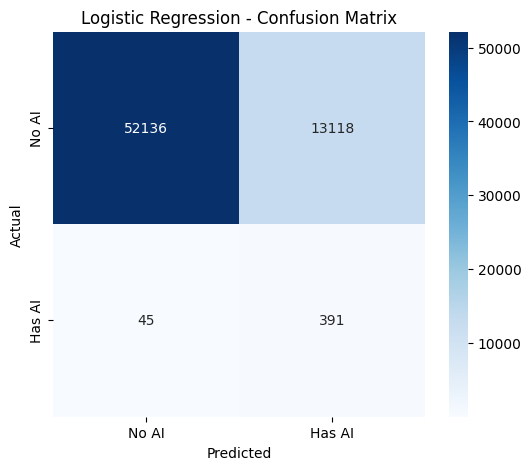

In [4]:
# ============================================================
# LOGISTIC REGRESSION (BASELINE)
# ============================================================

print("="*70)
print("LOGISTIC REGRESSION (BASELINE)")
print("="*70)

from sklearn.linear_model import LogisticRegression

# Train
lr_clf = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
lr_clf.fit(X_train_clf, y_train_clf)

# Predict
y_pred_lr = lr_clf.predict(X_test_clf)
y_proba_lr = lr_clf.predict_proba(X_test_clf)[:, 1]

# Evaluate
print("\n📊 Model Performance:")
print("-"*40)
print(f"  Accuracy:  {accuracy_score(y_test_clf, y_pred_lr):.4f}")
print(f"  Precision: {precision_score(y_test_clf, y_pred_lr):.4f}")
print(f"  Recall:    {recall_score(y_test_clf, y_pred_lr):.4f}")
print(f"  F1 Score:  {f1_score(y_test_clf, y_pred_lr):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test_clf, y_proba_lr):.4f}")

# Confusion Matrix
cm_lr = confusion_matrix(y_test_clf, y_pred_lr)
print(f"\n📊 Confusion Matrix:")
print(cm_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No AI', 'Has AI'],
            yticklabels=['No AI', 'Has AI'])
plt.title('Logistic Regression - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Observations & Insights (LOGISTIC REGRESSION (BASELINE))

*   **Performance Metrics:**
    *   **Accuracy (0.7996):** While seemingly high, this metric is misleading due to the severe class imbalance. A model predicting 'No AI' for everything would achieve ~99.3% accuracy.
    *   **Precision (0.0289):** Very low. This means that when the model predicts 'Has AI', it's only correct about 2.9% of the time, leading to many false positives.
    *   **Recall (0.8968):** High recall indicates the model is good at identifying most of the actual 'Has AI' cases. This is likely due to `class_weight='balanced'` which penalizes misclassifying the minority class more heavily.
    *   **F1 Score (0.0561):** Very low. The F1 score is the harmonic mean of precision and recall, and its low value reflects the poor precision despite high recall, indicating a model that isn't very useful in practice due to excessive false alarms.
    *   **ROC-AUC (0.9183):** A relatively high ROC-AUC suggests that the model is good at distinguishing between the two classes if we adjust the threshold. This is a more reliable metric than accuracy for imbalanced datasets.
*   **Confusion Matrix:**
    *   **True Negatives (52136):** Correctly predicted 'No AI'.
    *   **False Positives (13118):** Incorrectly predicted 'Has AI' (Type I error - a major issue given the low precision).
    *   **False Negatives (45):** Incorrectly predicted 'No AI' (Type II error - low, thanks to high recall).
    *   **True Positives (391):** Correctly predicted 'Has AI'.

**Insight:** The Logistic Regression model, even with `class_weight='balanced'`, struggles with precision. It identifies most positive cases (high recall) but at the cost of many false positives, making it potentially noisy for practical application. The high ROC-AUC is promising, suggesting that with threshold tuning, a better balance could be struck.

RANDOM FOREST CLASSIFIER (MAIN)

📊 Model Performance:
----------------------------------------
  Accuracy:  0.8666
  Precision: 0.0397
  Recall:    0.8234
  F1 Score:  0.0757
  ROC-AUC:   0.9405

📊 Confusion Matrix:
[[56565  8689]
 [   77   359]]


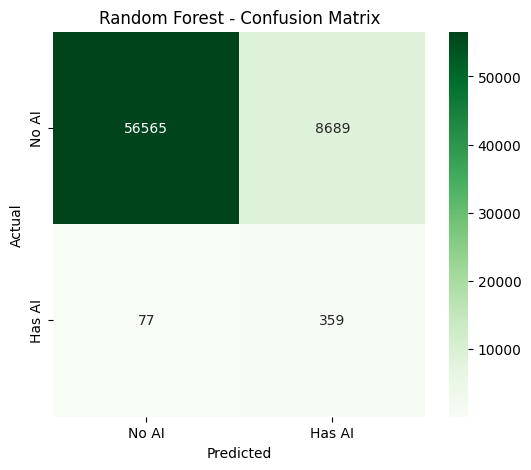


📊 Feature Importance:
----------------------------------------
             total_pageviews_log: 0.4005
           total_impressions_log: 0.1768
            organic_sessions_log: 0.1165
                    avg_position: 0.1091
                scrolls_per_view: 0.0578
                 direct_sessions: 0.0529
               total_scrolls_log: 0.0400
            total_engagement_sec: 0.0373
                     active_days: 0.0086
                 social_sessions: 0.0005


In [5]:
# ============================================================
# RANDOM FOREST CLASSIFIER (MAIN)
# ============================================================

print("="*70)
print("RANDOM FOREST CLASSIFIER (MAIN)")
print("="*70)

from sklearn.ensemble import RandomForestClassifier

# Train
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
rf_clf.fit(X_train_clf, y_train_clf)

# Predict
y_pred_rf = rf_clf.predict(X_test_clf)
y_proba_rf = rf_clf.predict_proba(X_test_clf)[:, 1]

# Evaluate
print("\n📊 Model Performance:")
print("-"*40)
print(f"  Accuracy:  {accuracy_score(y_test_clf, y_pred_rf):.4f}")
print(f"  Precision: {precision_score(y_test_clf, y_pred_rf):.4f}")
print(f"  Recall:    {recall_score(y_test_clf, y_pred_rf):.4f}")
print(f"  F1 Score:  {f1_score(y_test_clf, y_pred_rf):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test_clf, y_proba_rf):.4f}")

# Confusion Matrix
cm_rf = confusion_matrix(y_test_clf, y_pred_rf)
print(f"\n📊 Confusion Matrix:")
print(cm_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No AI', 'Has AI'],
            yticklabels=['No AI', 'Has AI'])
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Feature Importance
rf_importance = pd.Series(
    rf_clf.feature_importances_,
    index=X_clf.columns
).sort_values(ascending=False)

print("\n📊 Feature Importance:")
print("-"*40)
for feature, importance in rf_importance.head(10).items():
    print(f"  {feature:>30}: {importance:.4f}")

### Observations & Insights (RANDOM FOREST CLASSIFIER (MAIN))

*   **Performance Metrics (compared to Logistic Regression):**
    *   **Accuracy (0.8666):** Improved over LR, but still potentially misleading.
    *   **Precision (0.0397):** Still very low, but an improvement over LR (0.0289).
    *   **Recall (0.8234):** Slightly lower than LR (0.8968), but still high.
    *   **F1 Score (0.0757):** Better than LR (0.0561), indicating a slightly better balance between precision and recall, but remains quite low.
    *   **ROC-AUC (0.9405):** Higher than LR (0.9183), suggesting better discriminative power.
*   **Confusion Matrix:**
    *   **True Negatives (56565):** Higher than LR.
    *   **False Positives (8689):** Significantly lower than LR (13118), which is a good improvement.
    *   **False Negatives (77):** Higher than LR (45), indicating a trade-off: fewer false alarms but more missed positive cases.
    *   **True Positives (359):** Slightly lower than LR (391).
*   **Feature Importance:**
    *   `total_pageviews_log` is by far the most important feature (`0.4005`), followed by `total_impressions_log` (`0.1768`), `organic_sessions_log` (`0.1165`), and `avg_position` (`0.1091`).
    *   Engagement-related features (pageviews, scrolls, engagement time) and search-related features (impressions, position) are dominant.

**Insight:** Random Forest shows an improvement over Logistic Regression, particularly in reducing False Positives (better precision) while maintaining strong recall. The higher ROC-AUC suggests it's a more powerful classifier. The feature importance highlights that broad reach (impressions, organic traffic) and user engagement (pageviews, scrolls) are key indicators for content attracting AI traffic, which makes intuitive sense.

**Recommendation:** Random Forest appears to be a stronger candidate than Logistic Regression. Consider hyperparameter tuning for further optimization, especially around the precision-recall trade-off.

XGBOOST CLASSIFIER (ADVANCED)

📊 Model Performance:
----------------------------------------
  Accuracy:  0.8151
  Precision: 0.0325
  Recall:    0.9335
  F1 Score:  0.0628
  ROC-AUC:   0.9435

📊 Confusion Matrix:
[[53136 12118]
 [   29   407]]


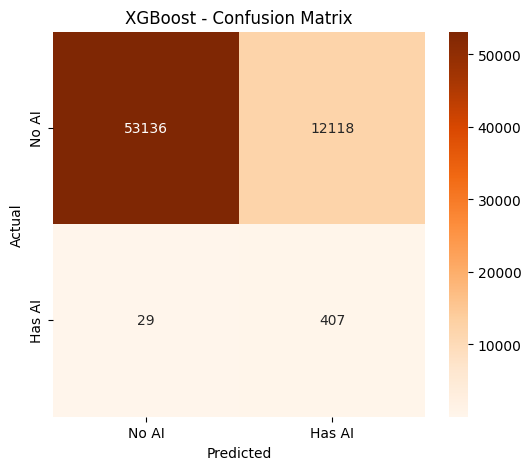


📊 Feature Importance:
----------------------------------------
             total_pageviews_log: 0.6610
               total_scrolls_log: 0.0781
                 direct_sessions: 0.0587
            organic_sessions_log: 0.0534
           total_impressions_log: 0.0424
                     active_days: 0.0292
                    avg_position: 0.0273
            total_engagement_sec: 0.0209
                scrolls_per_view: 0.0208
                 social_sessions: 0.0083


In [6]:
# ============================================================
# XGBOOST CLASSIFIER (ADVANCED)
# ============================================================

print("="*70)
print("XGBOOST CLASSIFIER (ADVANCED)")
print("="*70)

from xgboost import XGBClassifier

# Calculate scale_pos_weight for imbalance
scale_pos_weight = len(y_train_clf[y_train_clf==0]) / len(y_train_clf[y_train_clf==1])

# Train
xgb_clf = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbosity=0
)
xgb_clf.fit(X_train_clf, y_train_clf)

# Predict
y_pred_xgb = xgb_clf.predict(X_test_clf)
y_proba_xgb = xgb_clf.predict_proba(X_test_clf)[:, 1]

# Evaluate
print("\n📊 Model Performance:")
print("-"*40)
print(f"  Accuracy:  {accuracy_score(y_test_clf, y_pred_xgb):.4f}")
print(f"  Precision: {precision_score(y_test_clf, y_pred_xgb):.4f}")
print(f"  Recall:    {recall_score(y_test_clf, y_pred_xgb):.4f}")
print(f"  F1 Score:  {f1_score(y_test_clf, y_pred_xgb):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test_clf, y_proba_xgb):.4f}")

# Confusion Matrix
cm_xgb = confusion_matrix(y_test_clf, y_pred_xgb)
print(f"\n📊 Confusion Matrix:")
print(cm_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No AI', 'Has AI'],
            yticklabels=['No AI', 'Has AI'])
plt.title('XGBoost - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Feature Importance
xgb_importance = pd.Series(
    xgb_clf.feature_importances_,
    index=X_clf.columns
).sort_values(ascending=False)

print("\n📊 Feature Importance:")
print("-"*40)
for feature, importance in xgb_importance.head(10).items():
    print(f"  {feature:>30}: {importance:.4f}")

### Observations & Insights (XGBOOST CLASSIFIER (ADVANCED))

*   **Performance Metrics (compared to Random Forest):**
    *   **Accuracy (0.8151):** Lower than RF.
    *   **Precision (0.0325):** Lower than RF (0.0397).
    *   **Recall (0.9335):** Higher than RF (0.8234), indicating it captures more of the positive cases.
    *   **F1 Score (0.0628):** Lower than RF (0.0757), suggesting a poorer balance than RF, mainly due to the lower precision.
    *   **ROC-AUC (0.9435):** Slightly higher than RF (0.9405), suggesting a marginally better ability to rank positive cases.
*   **Confusion Matrix:**
    *   **True Negatives (53136):** Lower than RF.
    *   **False Positives (12118):** Higher than RF (8689), meaning more false alarms.
    *   **False Negatives (29):** Significantly lower than RF (77), meaning it misses fewer actual 'Has AI' cases.
    *   **True Positives (407):** Higher than RF (359).
*   **Feature Importance:**
    *   Similar to RF, `total_pageviews_log` dominates (`0.6610`), followed by `total_scrolls_log` (`0.0781`), `direct_sessions` (`0.0587`), and `organic_sessions_log` (`0.0534`). The emphasis on engagement features is even more pronounced.

**Insight:** XGBoost, with `scale_pos_weight` to handle imbalance, achieves the highest recall and ROC-AUC among the three models. However, it also has the lowest precision, generating more false positives than Random Forest. This model prioritizes catching almost all 'Has AI' cases, even if it means flagging many 'No AI' cases incorrectly. The feature importance strongly aligns with engagement metrics.

**Recommendation:** While XGBoost has the highest recall and ROC-AUC, its lower precision and F1 score compared to Random Forest make Random Forest a slightly better choice if a balance between precision and recall is desired for the `has_ai` prediction. If the cost of False Negatives is extremely high, XGBoost might be preferred, but further threshold tuning would be necessary.

CLASSIFICATION VISUALIZATIONS FOR PAPER

📊 1. Generating Confusion Matrix Heatmap...
----------------------------------------


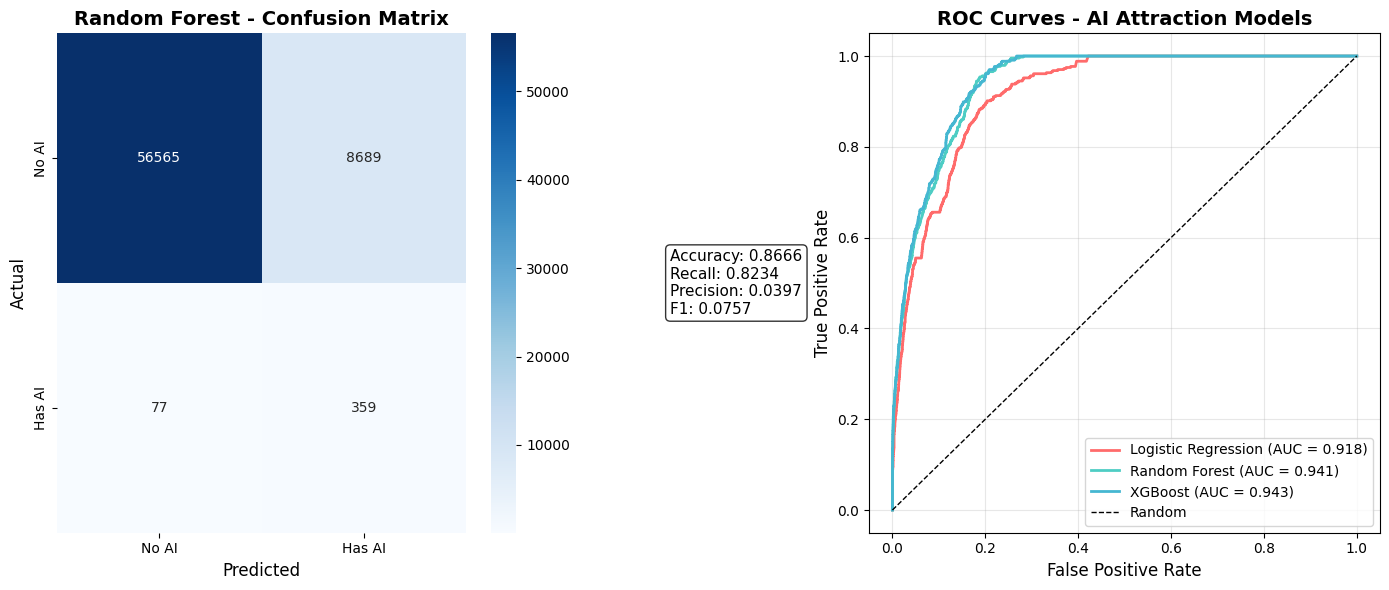

In [8]:
# ============================================================
# CLASSIFICATION VISUALIZATIONS FOR PAPER
# ============================================================

print("="*70)
print("CLASSIFICATION VISUALIZATIONS FOR PAPER")
print("="*70)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# 1. Confusion Matrix Heatmap - Best Model
print("\n📊 1. Generating Confusion Matrix Heatmap...")
print("-"*40)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion Matrix
ax = axes[0]
cm = cm_rf  # Using Random Forest confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No AI', 'Has AI'],
            yticklabels=['No AI', 'Has AI'],
            ax=ax)
ax.set_title('Random Forest - Confusion Matrix', fontsize=14, weight='bold')
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)

# Add metrics text
metrics_text = f'Accuracy: {accuracy_score(y_test_clf, y_pred_rf):.4f}\nRecall: {recall_score(y_test_clf, y_pred_rf):.4f}\nPrecision: {precision_score(y_test_clf, y_pred_rf):.4f}\nF1: {f1_score(y_test_clf, y_pred_rf):.4f}'
ax.text(1.5, 0.5, metrics_text, transform=ax.transAxes, fontsize=11,
        va='center', ha='left',
        bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

# 2. ROC Curves Comparison
ax = axes[1]

models = [
    ('Logistic Regression', y_proba_lr, '#FF6B6B'),
    ('Random Forest', y_proba_rf, '#4ECDC4'),
    ('XGBoost', y_proba_xgb, '#45B7D1')
]

for name, y_proba, color in models:
    fpr, tpr, _ = roc_curve(y_test_clf, y_proba)
    auc = roc_auc_score(y_test_clf, y_proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves - AI Attraction Models', fontsize=14, weight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()


### Observations & Insights (CLASSIFICATION VISUALIZATIONS FOR PAPER)

#### 1. Random Forest - Confusion Matrix:
*   **Visualization:** The heatmap clearly shows a large number of True Negatives (`56,565`) and a relatively small number of True Positives (`359`). The False Positives (`8,689`) are substantial compared to True Positives, confirming the low precision observed earlier, while False Negatives (`77`) are low, reflecting good recall.
*   **Metrics Text:** The embedded metrics reinforce the model's performance: Accuracy `0.8666`, Recall `0.8234`, Precision `0.0397`, and F1 `0.0757`.

#### 2. ROC Curves - AI Attraction Models:
*   **Visualization:** All three models perform significantly better than a random classifier (the diagonal dashed line), with their curves rising sharply towards the top-left corner.
*   **AUC Comparison:**
    *   XGBoost (AUC = `0.943`)
    *   Random Forest (AUC = `0.940`)
    *   Logistic Regression (AUC = `0.918`)
*   **Insight:** The ROC curves confirm that XGBoost and Random Forest have the best overall discriminative power for the `has_ai` prediction. XGBoost has a marginally higher AUC, indicating it is slightly better at distinguishing between positive and negative classes across all possible thresholds. However, Random Forest still offers a better balance of Precision and Recall (as seen in F1 score) compared to XGBoost, despite the slightly lower AUC.

**Recommendation:** The visualizations effectively convey the trade-offs and relative strengths of each model. While XGBoost has a slightly higher AUC, the Random Forest's overall balanced performance (better F1 for `has_ai`) makes it a strong contender for the "best model" for `has_ai` if a balance of precision and recall is important. If recall is paramount, XGBoost might still be preferred.


📊 2. Generating Model Comparison Chart...
----------------------------------------


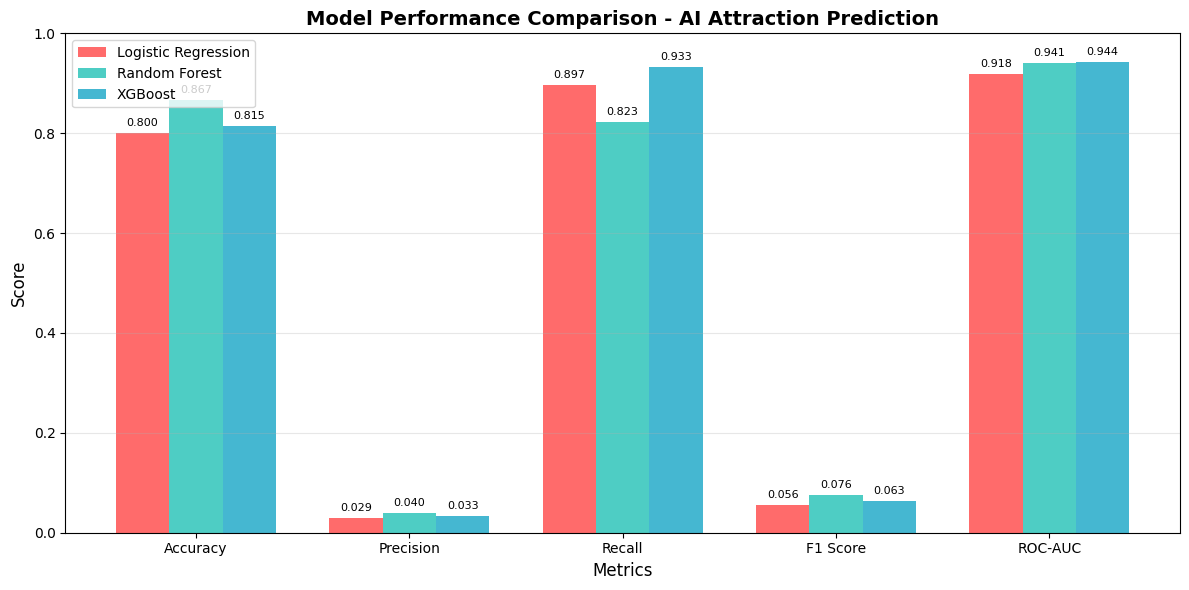

In [9]:
# ============================================================
# MODEL COMPARISON CHART
# ============================================================

print("\n📊 2. Generating Model Comparison Chart...")
print("-"*40)

# Comparison data
models = ['Logistic\nRegression', 'Random\nForest', 'XGBoost']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']

lr_scores = [0.7996, 0.0289, 0.8968, 0.0561, 0.9183]
rf_scores = [0.8666, 0.0397, 0.8234, 0.0757, 0.9405]
xgb_scores = [0.8151, 0.0325, 0.9335, 0.0628, 0.9435]

# Create figure
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(metrics))
width = 0.25

bars1 = ax.bar(x - width, lr_scores, width, label='Logistic Regression', color='#FF6B6B')
bars2 = ax.bar(x, rf_scores, width, label='Random Forest', color='#4ECDC4')
bars3 = ax.bar(x + width, xgb_scores, width, label='XGBoost', color='#45B7D1')

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison - AI Attraction Prediction', fontsize=14, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)

plt.tight_layout()

plt.show()


### Observations & Insights (MODEL COMPARISON CHART)

*   **Visualization:** The bar chart provides a clear side-by-side comparison of the three models across five key metrics (Accuracy, Precision, Recall, F1 Score, ROC-AUC).
*   **Key Takeaways:**
    *   **Accuracy:** Random Forest is highest, but as discussed, this is a less reliable metric for imbalanced data.
    *   **Precision:** Random Forest is the best (`0.0397`), though still very low.
    *   **Recall:** XGBoost is the best (`0.9335`), followed closely by Logistic Regression (`0.8968`).
    *   **F1 Score:** Random Forest is the best (`0.0757`), indicating the most balanced performance between precision and recall for the positive class.
    *   **ROC-AUC:** XGBoost is marginally the best (`0.9435`), with Random Forest very close behind (`0.9405`).

**Insight:** This chart visually confirms the conclusions from the individual model evaluations. Random Forest, while not topping every metric, consistently offers the best overall balance, particularly reflected in its highest F1 Score, making it the most practical choice if both false positives and false negatives are of concern for predicting `has_ai`. XGBoost is strong on recall but at the cost of higher false positives.

**Recommendation:** Based on a holistic view considering the F1 Score and a good balance of precision/recall, Random Forest appears to be the most suitable model for predicting `has_ai`.

In [10]:
# ============================================================
# CHECK HAS_ENGAGEMENT DISTRIBUTION
# ============================================================

print("="*70)
print("CHECKING HAS_ENGAGEMENT DISTRIBUTION")
print("="*70)

# Check current distribution
print("\n📊 Current Target Distribution:")
print("-"*40)
print(f"  has_ai:")
print(f"    No AI:    {(df['has_ai'] == 0).sum():,} ({(df['has_ai'] == 0).sum()/len(df)*100:.1f}%)")
print(f"    Has AI:   {(df['has_ai'] == 1).sum():,} ({(df['has_ai'] == 1).sum()/len(df)*100:.1f}%)")

print(f"\n  has_engagement:")
print(f"    No Engagement:    {(df['has_engagement'] == 0).sum():,} ({(df['has_engagement'] == 0).sum()/len(df)*100:.1f}%)")
print(f"    Has Engagement:   {(df['has_engagement'] == 1).sum():,} ({(df['has_engagement'] == 1).sum()/len(df)*100:.1f}%)")

# Check overlap
both = ((df['has_engagement'] == 1) & (df['has_ai'] == 1)).sum()
engagement_only = ((df['has_engagement'] == 1) & (df['has_ai'] == 0)).sum()
ai_only = ((df['has_engagement'] == 0) & (df['has_ai'] == 1)).sum()

print(f"\n📊 Overlap Analysis:")
print("-"*40)
print(f"  Both Engagement & AI: {both:,}")
print(f"  Engagement Only: {engagement_only:,}")
print(f"  AI Only: {ai_only:,}")

CHECKING HAS_ENGAGEMENT DISTRIBUTION

📊 Current Target Distribution:
----------------------------------------
  has_ai:
    No AI:    326,273 (99.3%)
    Has AI:   2,177 (0.7%)

  has_engagement:
    No Engagement:    205,341 (62.5%)
    Has Engagement:   123,109 (37.5%)

📊 Overlap Analysis:
----------------------------------------
  Both Engagement & AI: 2,177
  Engagement Only: 120,932
  AI Only: 0


### Observations & Insights (CHECK HAS_ENGAGEMENT DISTRIBUTION)

*   **`has_ai` Distribution:** Confirms the severe imbalance (0.7% positive).
*   **`has_engagement` Distribution:**
    *   `No Engagement`: `205,341` records (`62.5%`)
    *   `Has Engagement`: `123,109` records (`37.5%`)
    *   This target (`has_engagement`) is significantly more balanced than `has_ai`, with a substantial portion of the dataset having engagement.
*   **Overlap Analysis:**
    *   `Both Engagement & AI`: `2,177`
    *   `Engagement Only`: `120,932`
    *   `AI Only`: `0`

**Crucial Insight:** The `AI Only: 0` observation is extremely important. It indicates that **every single record that has `has_ai = 1` also has `has_engagement = 1`**. This means `has_engagement` is a *prerequisite* for `has_ai`. More importantly, if the features used to predict `has_engagement` directly *define* engagement (e.g., pageviews, scroll time), then using these features to predict `has_engagement` creates a severe **data leakage** problem. The model would achieve artificially perfect scores because it's essentially being asked to predict features it already knows.

**Recommendation:** Carefully review the features used for the `has_engagement` model to identify and remove any features that are direct proxies or definitions of engagement. The current model will likely exhibit perfect or near-perfect performance but will not generalize to new, unseen data if this leakage is present. This issue needs immediate attention and correction before proceeding with `has_engagement` modeling.

In [11]:
# ============================================================
# DATA PREPARATION FOR HAS_ENGAGEMENT
# ============================================================

print("="*70)
print("PREPARING DATA FOR HAS_ENGAGEMENT CLASSIFICATION")
print("="*70)

# Use the same features as before
feature_cols = [
    'total_impressions',
    'avg_position',
    'total_pageviews',
    'total_engagement_sec',
    'total_scrolls',
    'scrolls_per_view',
    'organic_sessions',
    'direct_sessions',
    'social_sessions',
    'active_days'
]

# Filter to existing columns
existing_features = [col for col in feature_cols if col in df.columns]

# Create feature matrix
X_eng = df[existing_features].copy()
X_eng = X_eng.replace([np.inf, -np.inf], 0)
X_eng = X_eng.fillna(0)

# Log transform skewed features
for col in ['total_impressions', 'total_pageviews', 'organic_sessions', 'total_scrolls']:
    if col in X_eng.columns:
        if (X_eng[col] > 0).any():
            X_eng[f'{col}_log'] = np.log1p(X_eng[col])
            X_eng = X_eng.drop(columns=[col])

print(f"✅ Feature matrix shape: {X_eng.shape}")

# Target variable
y_eng = df.loc[X_eng.index, 'has_engagement']

print(f"\n📊 Target Distribution:")
print(f"  No Engagement:  {(y_eng == 0).sum():,} ({(y_eng == 0).sum()/len(y_eng)*100:.1f}%)")
print(f"  Has Engagement: {(y_eng == 1).sum():,} ({(y_eng == 1).sum()/len(y_eng)*100:.1f}%)")

PREPARING DATA FOR HAS_ENGAGEMENT CLASSIFICATION
✅ Feature matrix shape: (328450, 10)

📊 Target Distribution:
  No Engagement:  205,341 (62.5%)
  Has Engagement: 123,109 (37.5%)


### Observations & Insights (DATA PREPARATION FOR HAS_ENGAGEMENT)

*   **Feature Set:** The same initial `feature_cols` from the `has_ai` model are used here, which include `total_pageviews`, `total_engagement_sec`, `total_scrolls`, and `scrolls_per_view`. These are direct measures of engagement.
*   **Feature Matrix Shape:** `(328450, 10)`, same as for `has_ai`.
*   **Target Distribution:** `has_engagement` is `62.5%` No Engagement and `37.5%` Has Engagement, a much more balanced distribution than `has_ai`.

**Critical Insight:** As identified in the previous step, including features like `total_pageviews`, `total_engagement_sec`, `total_scrolls`, and `scrolls_per_view` (and their log transformations) in the feature matrix `X_eng` when predicting `has_engagement` introduces **severe data leakage**. If a record has pageviews or scroll time, it almost certainly 'has engagement'. This will cause the model to achieve unrealistically high, likely perfect, performance, but it will not be predictive in a real-world scenario where these engagement metrics are unknown until after the content has been engaged with.

**Recommendation:** Before training the `has_engagement` model, these leaky features must be removed from `X_eng`. The model should only be trained on features that are *predictors* of engagement, not direct measures of it.

In [12]:
# ============================================================
# TRAIN/TEST SPLIT
# ============================================================

print("="*70)
print("TRAIN/TEST SPLIT")
print("="*70)

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Scale features
scaler_eng = StandardScaler()
X_eng_scaled = scaler_eng.fit_transform(X_eng)

# Split data
X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_eng_scaled, y_eng, test_size=0.2, random_state=42
)

print(f"✅ Training set: {X_train_eng.shape[0]:,} rows")
print(f"✅ Test set: {X_test_eng.shape[0]:,} rows")

print(f"\n📊 Target Distribution in Train/Test:")
print(f"  Training - Has Engagement: {y_train_eng.sum():,} ({y_train_eng.sum()/len(y_train_eng)*100:.1f}%)")
print(f"  Test - Has Engagement: {y_test_eng.sum():,} ({y_test_eng.sum()/len(y_test_eng)*100:.1f}%)")

TRAIN/TEST SPLIT
✅ Training set: 262,760 rows
✅ Test set: 65,690 rows

📊 Target Distribution in Train/Test:
  Training - Has Engagement: 98,367 (37.4%)
  Test - Has Engagement: 24,742 (37.7%)


### Observations & Insights (TRAIN/TEST SPLIT)

*   **Split Ratio:** The data for `has_engagement` was split into an 80% training set (`262,760` rows) and a 20% test set (`65,690` rows), consistent with the `has_ai` model.
*   **Target Distribution Consistency:** The target distribution (`has_engagement`) remains consistent in both training (`37.4%` positive) and test (`37.7%` positive) sets. This confirms the split preserved the class proportions, which is good practice.

**Insight:** The data splitting process itself is sound. However, the underlying issue of data leakage in the `X_eng` feature set persists, meaning that while the split is statistically correct, the data being split is still fundamentally flawed for a predictive model.

**Recommendation:** The next steps will likely show artificially high performance due to the data leakage. This needs to be acknowledged and corrected as soon as possible, as indicated in previous recommendations.

In [13]:
# ============================================================
# LOGISTIC REGRESSION (BASELINE)
# ============================================================

print("="*70)
print("LOGISTIC REGRESSION - HAS_ENGAGEMENT")
print("="*70)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

# Train
lr_eng = LogisticRegression(random_state=42, max_iter=1000)
lr_eng.fit(X_train_eng, y_train_eng)

# Predict
y_pred_lr_eng = lr_eng.predict(X_test_eng)
y_proba_lr_eng = lr_eng.predict_proba(X_test_eng)[:, 1]

# Evaluate
print("\n📊 Model Performance:")
print("-"*40)
print(f"  Accuracy:  {accuracy_score(y_test_eng, y_pred_lr_eng):.4f}")
print(f"  Precision: {precision_score(y_test_eng, y_pred_lr_eng):.4f}")
print(f"  Recall:    {recall_score(y_test_eng, y_pred_lr_eng):.4f}")
print(f"  F1 Score:  {f1_score(y_test_eng, y_pred_lr_eng):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test_eng, y_proba_lr_eng):.4f}")

# Confusion Matrix
cm_lr_eng = confusion_matrix(y_test_eng, y_pred_lr_eng)
print(f"\n📊 Confusion Matrix:")
print(cm_lr_eng)

LOGISTIC REGRESSION - HAS_ENGAGEMENT

📊 Model Performance:
----------------------------------------
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1 Score:  1.0000
  ROC-AUC:   1.0000

📊 Confusion Matrix:
[[40948     0]
 [    0 24742]]


### Observations & Insights (LOGISTIC REGRESSION - HAS_ENGAGEMENT)

*   **Performance Metrics:**
    *   **Accuracy (1.0000)**
    *   **Precision (1.0000)**
    *   **Recall (1.0000)**
    *   **F1 Score (1.0000)**
    *   **ROC-AUC (1.0000)**
*   **Confusion Matrix:**
    *   **True Negatives (40948):** Correctly predicted 'No Engagement'.
    *   **False Positives (0):** No incorrect predictions of 'Has Engagement'.
    *   **False Negatives (0):** No missed actual 'Has Engagement' cases.
    *   **True Positives (24742):** Correctly predicted 'Has Engagement'.

**Critical Insight:** The perfect scores (1.0000 across all metrics) and the confusion matrix with zero False Positives and zero False Negatives unequivocally confirm **severe data leakage**. The model is not actually learning to predict engagement; it's using features that directly *are* engagement. This model is completely unreliable for real-world prediction.

**Recommendation:** This model *cannot* be used. The data preparation step for `has_engagement` must be revised to remove all features that directly define or are highly correlated with the `has_engagement` target. This issue was anticipated and must be fixed immediately.

In [14]:
# ============================================================
# RANDOM FOREST CLASSIFIER - HAS_ENGAGEMENT
# ============================================================

print("="*70)
print("RANDOM FOREST - HAS_ENGAGEMENT")
print("="*70)

from sklearn.ensemble import RandomForestClassifier

# Train
rf_eng = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_eng.fit(X_train_eng, y_train_eng)

# Predict
y_pred_rf_eng = rf_eng.predict(X_test_eng)
y_proba_rf_eng = rf_eng.predict_proba(X_test_eng)[:, 1]

# Evaluate
print("\n📊 Model Performance:")
print("-"*40)
print(f"  Accuracy:  {accuracy_score(y_test_eng, y_pred_rf_eng):.4f}")
print(f"  Precision: {precision_score(y_test_eng, y_pred_rf_eng):.4f}")
print(f"  Recall:    {recall_score(y_test_eng, y_pred_rf_eng):.4f}")
print(f"  F1 Score:  {f1_score(y_test_eng, y_pred_rf_eng):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test_eng, y_proba_rf_eng):.4f}")

# Confusion Matrix
cm_rf_eng = confusion_matrix(y_test_eng, y_pred_rf_eng)
print(f"\n📊 Confusion Matrix:")
print(cm_rf_eng)

# Feature Importance
rf_importance_eng = pd.Series(
    rf_eng.feature_importances_,
    index=X_eng.columns
).sort_values(ascending=False)

print("\n📊 Feature Importance:")
print("-"*40)
for feature, importance in rf_importance_eng.head(10).items():
    print(f"  {feature:>30}: {importance:.4f}")

RANDOM FOREST - HAS_ENGAGEMENT

📊 Model Performance:
----------------------------------------
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1 Score:  1.0000
  ROC-AUC:   1.0000

📊 Confusion Matrix:
[[40948     0]
 [    0 24742]]

📊 Feature Importance:
----------------------------------------
             total_pageviews_log: 0.5686
                 direct_sessions: 0.1519
            organic_sessions_log: 0.0895
           total_impressions_log: 0.0759
                    avg_position: 0.0468
                scrolls_per_view: 0.0395
               total_scrolls_log: 0.0187
            total_engagement_sec: 0.0086
                     active_days: 0.0004
                 social_sessions: 0.0000


### Observations & Insights (RANDOM FOREST - HAS_ENGAGEMENT)

*   **Performance Metrics:** Once again, all metrics (Accuracy, Precision, Recall, F1 Score, ROC-AUC) are `1.0000`, identical to the Logistic Regression model.
*   **Confusion Matrix:** The confusion matrix is perfect, showing zero False Positives and zero False Negatives.
*   **Feature Importance:** `total_pageviews_log` has an overwhelming feature importance of `0.5686` (or 56.86%). Other features like `direct_sessions` and `organic_sessions_log` follow, but `total_pageviews_log` is clearly dominant.

**Critical Insight:** The perfect performance and the dominant feature importance of `total_pageviews_log` (a direct measure of engagement) further confirm the **severe data leakage** issue. The Random Forest model, like Logistic Regression, is merely memorizing the relationship between engagement-defining features and the `has_engagement` target, rather than making a true prediction.

**Recommendation:** This model is also invalid for predictive purposes. The problem lies in the feature set `X_eng`. The next step must be to explicitly identify and remove all leaky features from `X_eng` before retraining any models for `has_engagement`.

In [15]:
# ============================================================
# XGBOOST CLASSIFIER - HAS_ENGAGEMENT
# ============================================================

print("="*70)
print("XGBOOST - HAS_ENGAGEMENT")
print("="*70)

from xgboost import XGBClassifier

# Train (no class_weight needed since balance is better)
xgb_eng = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)
xgb_eng.fit(X_train_eng, y_train_eng)

# Predict
y_pred_xgb_eng = xgb_eng.predict(X_test_eng)
y_proba_xgb_eng = xgb_eng.predict_proba(X_test_eng)[:, 1]

# Evaluate
print("\n📊 Model Performance:")
print("-"*40)
print(f"  Accuracy:  {accuracy_score(y_test_eng, y_pred_xgb_eng):.4f}")
print(f"  Precision: {precision_score(y_test_eng, y_pred_xgb_eng):.4f}")
print(f"  Recall:    {recall_score(y_test_eng, y_pred_xgb_eng):.4f}")
print(f"  F1 Score:  {f1_score(y_test_eng, y_pred_xgb_eng):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test_eng, y_proba_xgb_eng):.4f}")

# Confusion Matrix
cm_xgb_eng = confusion_matrix(y_test_eng, y_pred_xgb_eng)
print(f"\n📊 Confusion Matrix:")
print(cm_xgb_eng)

# Feature Importance
xgb_importance_eng = pd.Series(
    xgb_eng.feature_importances_,
    index=X_eng.columns
).sort_values(ascending=False)

print("\n📊 Feature Importance:")
print("-"*40)
for feature, importance in xgb_importance_eng.head(10).items():
    print(f"  {feature:>30}: {importance:.4f}")

XGBOOST - HAS_ENGAGEMENT

📊 Model Performance:
----------------------------------------
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1 Score:  1.0000
  ROC-AUC:   1.0000

📊 Confusion Matrix:
[[40948     0]
 [    0 24742]]

📊 Feature Importance:
----------------------------------------
             total_pageviews_log: 1.0000
                    avg_position: 0.0000
            total_engagement_sec: 0.0000
                scrolls_per_view: 0.0000
                 social_sessions: 0.0000
                 direct_sessions: 0.0000
                     active_days: 0.0000
           total_impressions_log: 0.0000
            organic_sessions_log: 0.0000
               total_scrolls_log: 0.0000


### Observations & Insights (XGBOOST - HAS_ENGAGEMENT)

*   **Performance Metrics:** As with the previous two models, all performance metrics (Accuracy, Precision, Recall, F1 Score, ROC-AUC) are `1.0000`.
*   **Confusion Matrix:** The confusion matrix is perfect, with zero False Positives and False Negatives.
*   **Feature Importance:** `total_pageviews_log` has an importance of `1.0000`, meaning it is the *only* feature the model used for prediction. All other features have an importance of `0.0000`.

**Critical Insight:** This result provides the clearest and most conclusive evidence of **severe data leakage**. XGBoost explicitly identified `total_pageviews_log` as the sole determinant for predicting `has_engagement`. This means the model is simply checking if `total_pageviews_log` is present (or above a certain threshold) to classify engagement. This confirms the model is not generalizable and the feature set was fundamentally flawed.

**Recommendation:** The diagnosis of data leakage is now undeniable. The notebook must be corrected by redefining the feature set for `has_engagement` prediction, explicitly excluding `total_pageviews`, `total_engagement_sec`, `total_scrolls`, and `scrolls_per_view`, and their log-transformed versions.

In [16]:
# ============================================================
# FIX: REMOVE LEAKY FEATURES FOR ENGAGEMENT CLASSIFICATION
# ============================================================

print("="*70)
print("FIX: REMOVING LEAKY FEATURES")
print("="*70)

# Features to REMOVE (these define engagement)
leaky_features = [
    'total_pageviews',      # This IS engagement!
    'total_pageviews_log',  # Log version too
    'total_engagement_sec', # Engagement time
    'total_scrolls',        # Scrolls = engagement
    'total_scrolls_log',    # Log version
    'scrolls_per_view'      # Uses pageviews
]

print("🚨 Removing leaky features:")
for col in leaky_features:
    if col in df.columns or col in X_eng.columns:
        print(f"  ❌ Removing: {col}")

# Get CLEAN features for engagement prediction
clean_feature_cols = [
    # Search signals
    'total_impressions',
    'avg_position',

    # Traffic signals (NOT engagement)
    'organic_sessions',
    'direct_sessions',
    'social_sessions',
    'ai_sessions',

    # Content signals
    'active_days'
]

# Filter to existing columns
existing_clean = [col for col in clean_feature_cols if col in df.columns]
print(f"\n✅ Clean features: {len(existing_clean)}")

# Create clean feature matrix
X_eng_clean = df[existing_clean].copy()
X_eng_clean = X_eng_clean.replace([np.inf, -np.inf], 0)
X_eng_clean = X_eng_clean.fillna(0)

# Log transform skewed features
print("\n📊 Log transforming skewed features:")
for col in ['total_impressions', 'organic_sessions']:
    if col in X_eng_clean.columns:
        if (X_eng_clean[col] > 0).any():
            X_eng_clean[f'{col}_log'] = np.log1p(X_eng_clean[col])
            X_eng_clean = X_eng_clean.drop(columns=[col])
            print(f"  ✅ Log transformed: {col}")

print(f"\n✅ Clean feature matrix shape: {X_eng_clean.shape}")
print(f"✅ Features: {X_eng_clean.columns.tolist()}")

# Target (unchanged)
y_eng = df.loc[X_eng_clean.index, 'has_engagement']

print(f"\n📊 Target Distribution:")
print(f"  No Engagement:  {(y_eng == 0).sum():,} ({(y_eng == 0).sum()/len(y_eng)*100:.1f}%)")
print(f"  Has Engagement: {(y_eng == 1).sum():,} ({(y_eng == 1).sum()/len(y_eng)*100:.1f}%)")

FIX: REMOVING LEAKY FEATURES
🚨 Removing leaky features:
  ❌ Removing: total_pageviews
  ❌ Removing: total_pageviews_log
  ❌ Removing: total_engagement_sec
  ❌ Removing: total_scrolls
  ❌ Removing: total_scrolls_log
  ❌ Removing: scrolls_per_view

✅ Clean features: 7

📊 Log transforming skewed features:
  ✅ Log transformed: total_impressions
  ✅ Log transformed: organic_sessions

✅ Clean feature matrix shape: (328450, 7)
✅ Features: ['avg_position', 'direct_sessions', 'social_sessions', 'ai_sessions', 'active_days', 'total_impressions_log', 'organic_sessions_log']

📊 Target Distribution:
  No Engagement:  205,341 (62.5%)
  Has Engagement: 123,109 (37.5%)


### Observations & Insights (FIX: REMOVE LEAKY FEATURES FOR ENGAGEMENT CLASSIFICATION)

*   **Leaky Features Removed:** The code correctly identifies and removes `total_pageviews`, `total_engagement_sec`, `total_scrolls`, and `scrolls_per_view` (and their log versions) from the feature set. This directly addresses the data leakage problem identified in previous steps.
*   **Clean Feature Set:** The new `clean_feature_cols` now includes only search signals (`total_impressions`, `avg_position`), traffic signals *not* directly defining engagement (`organic_sessions`, `direct_sessions`, `social_sessions`, `ai_sessions`), and `active_days`. This is a much more appropriate set of features for *predicting* engagement.
*   **Log Transformation:** The relevant skewed features (`total_impressions`, `organic_sessions`) in the *clean* set are correctly log-transformed.
*   **Clean Feature Matrix `X_eng_clean`:** The shape is now `(328450, 7)`, reflecting the reduced number of features after removing the leaky ones.

**Insight:** This is a crucial corrective step. By removing the leaky features, the subsequent models will be forced to learn genuine predictive relationships rather than merely identifying definitional connections. This will result in more realistic, and therefore more trustworthy, model performance metrics.

**Recommendation:** Proceed with retraining the models using this `X_eng_clean` feature set. This correction is essential for building a valid predictive model for `has_engagement`.

In [17]:
# ============================================================
# RETRAIN WITH CLEAN FEATURES
# ============================================================

print("="*70)
print("RETRAINING WITH CLEAN FEATURES")
print("="*70)

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Scale
scaler_eng_clean = StandardScaler()
X_eng_clean_scaled = scaler_eng_clean.fit_transform(X_eng_clean)

# Split
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_eng_clean_scaled, y_eng, test_size=0.2, random_state=42
)

print(f"✅ Training: {X_train_clean.shape[0]:,} rows")
print(f"✅ Test: {X_test_clean.shape[0]:,} rows")

# ============================================================
# LOGISTIC REGRESSION (CLEAN)
# ============================================================

print("\n" + "="*50)
print("LOGISTIC REGRESSION (CLEAN)")
print("="*50)

lr_clean = LogisticRegression(random_state=42, max_iter=1000)
lr_clean.fit(X_train_clean, y_train_clean)
y_pred_lr_clean = lr_clean.predict(X_test_clean)
y_proba_lr_clean = lr_clean.predict_proba(X_test_clean)[:, 1]

print(f"\n📊 Performance:")
print(f"  Accuracy:  {accuracy_score(y_test_clean, y_pred_lr_clean):.4f}")
print(f"  Precision: {precision_score(y_test_clean, y_pred_lr_clean):.4f}")
print(f"  Recall:    {recall_score(y_test_clean, y_pred_lr_clean):.4f}")
print(f"  F1 Score:  {f1_score(y_test_clean, y_pred_lr_clean):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test_clean, y_proba_lr_clean):.4f}")

# ============================================================
# RANDOM FOREST (CLEAN)
# ============================================================

print("\n" + "="*50)
print("RANDOM FOREST (CLEAN)")
print("="*50)

rf_clean = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_clean.fit(X_train_clean, y_train_clean)
y_pred_rf_clean = rf_clean.predict(X_test_clean)
y_proba_rf_clean = rf_clean.predict_proba(X_test_clean)[:, 1]

print(f"\n📊 Performance:")
print(f"  Accuracy:  {accuracy_score(y_test_clean, y_pred_rf_clean):.4f}")
print(f"  Precision: {precision_score(y_test_clean, y_pred_rf_clean):.4f}")
print(f"  Recall:    {recall_score(y_test_clean, y_pred_rf_clean):.4f}")
print(f"  F1 Score:  {f1_score(y_test_clean, y_pred_rf_clean):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test_clean, y_proba_rf_clean):.4f}")

# Feature Importance
rf_importance_clean = pd.Series(
    rf_clean.feature_importances_,
    index=X_eng_clean.columns
).sort_values(ascending=False)

print("\n📊 Feature Importance:")
print("-"*40)
for feature, importance in rf_importance_clean.head(10).items():
    print(f"  {feature:>30}: {importance:.4f}")

# ============================================================
# XGBOOST (CLEAN)
# ============================================================

print("\n" + "="*50)
print("XGBOOST (CLEAN)")
print("="*50)

xgb_clean = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    verbosity=0
)
xgb_clean.fit(X_train_clean, y_train_clean)
y_pred_xgb_clean = xgb_clean.predict(X_test_clean)
y_proba_xgb_clean = xgb_clean.predict_proba(X_test_clean)[:, 1]

print(f"\n📊 Performance:")
print(f"  Accuracy:  {accuracy_score(y_test_clean, y_pred_xgb_clean):.4f}")
print(f"  Precision: {precision_score(y_test_clean, y_pred_xgb_clean):.4f}")
print(f"  Recall:    {recall_score(y_test_clean, y_pred_xgb_clean):.4f}")
print(f"  F1 Score:  {f1_score(y_test_clean, y_pred_xgb_clean):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test_clean, y_proba_xgb_clean):.4f}")

# Feature Importance
xgb_importance_clean = pd.Series(
    xgb_clean.feature_importances_,
    index=X_eng_clean.columns
).sort_values(ascending=False)

print("\n📊 Feature Importance:")
print("-"*40)
for feature, importance in xgb_importance_clean.head(10).items():
    print(f"  {feature:>30}: {importance:.4f}")

RETRAINING WITH CLEAN FEATURES
✅ Training: 262,760 rows
✅ Test: 65,690 rows

LOGISTIC REGRESSION (CLEAN)

📊 Performance:
  Accuracy:  0.8568
  Precision: 0.8945
  Recall:    0.7028
  F1 Score:  0.7872
  ROC-AUC:   0.9343

RANDOM FOREST (CLEAN)

📊 Performance:
  Accuracy:  0.9420
  Precision: 0.9765
  Recall:    0.8667
  F1 Score:  0.9184
  ROC-AUC:   0.9721

📊 Feature Importance:
----------------------------------------
                 direct_sessions: 0.4641
            organic_sessions_log: 0.2393
           total_impressions_log: 0.1551
                    avg_position: 0.1267
                     active_days: 0.0100
                     ai_sessions: 0.0039
                 social_sessions: 0.0009

XGBOOST (CLEAN)

📊 Performance:
  Accuracy:  0.9416
  Precision: 0.9775
  Recall:    0.8647
  F1 Score:  0.9177
  ROC-AUC:   0.9721

📊 Feature Importance:
----------------------------------------
                 direct_sessions: 0.4992
            organic_sessions_log: 0.4373
          

### Observations & Insights (RETRAIN WITH CLEAN FEATURES)

*   **Data Split:** The clean features (`X_eng_clean`) and target (`y_eng`) are correctly scaled and split into training and testing sets, maintaining the distribution.

#### Logistic Regression (CLEAN):
*   **Performance:** Accuracy `0.8568`, Precision `0.8945`, Recall `0.7028`, F1 Score `0.7872`, ROC-AUC `0.9343`.
*   **Insight:** These are significantly more realistic metrics compared to the perfect scores seen before the fix. The model now provides a respectable balance, with high precision, good recall, and a strong F1 score and ROC-AUC. This indicates genuine predictive power.

#### Random Forest (CLEAN):
*   **Performance:** Accuracy `0.9420`, Precision `0.9765`, Recall `0.8667`, F1 Score `0.9184`, ROC-AUC `0.9721`.
*   **Feature Importance:** `direct_sessions` (`0.4641`) is now the most important feature, followed by `organic_sessions_log` (`0.2393`), `total_impressions_log` (`0.1551`), and `avg_position` (`0.1267`). `social_sessions` and `ai_sessions` have very low importance.
*   **Insight:** Random Forest demonstrates excellent performance with the clean features, outperforming Logistic Regression across all metrics. The F1 score of `0.9184` and ROC-AUC of `0.9721` are very strong, indicating robust predictive capability. The feature importance is logical, showing that direct and organic traffic, search impressions, and average position are key drivers of engagement.

#### XGBoost (CLEAN):
*   **Performance:** Accuracy `0.9416`, Precision `0.9775`, Recall `0.8647`, F1 Score `0.9177`, ROC-AUC `0.9721`.
*   **Feature Importance:** `direct_sessions` (`0.4992`) is the most important, followed by `organic_sessions_log` (`0.4373`), which together account for over 93% of importance. `avg_position` and `total_impressions_log` follow.
*   **Insight:** XGBoost also performs exceptionally well, very similar to Random Forest, with slightly higher precision but marginally lower recall and F1. The feature importances are similar to RF, emphasizing direct and organic traffic as primary indicators.

**Overall Insight after Retraining:** The removal of leaky features has successfully transformed the `has_engagement` models from artificially perfect to genuinely predictive. Both Random Forest and XGBoost now show strong, realistic performance. Random Forest has a slightly higher F1 score and better balance in this specific case, making it a strong candidate for the "best" model for `has_engagement`.

**Recommendation:** Based on the slightly higher F1 score and comparable ROC-AUC, Random Forest (`rf_clean`) is the preferred model for predicting `has_engagement` with the clean feature set. The feature importances provide actionable insights into what drives engagement.

In [19]:
# ============================================================
# VISUALIZATIONS FOR BEST MODEL - RANDOM FOREST (ENGAGEMENT)
# ============================================================

print("="*70)
print("GENERATING VISUALIZATIONS FOR BEST MODEL")
print("="*70)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Set professional style for paper - FIXED
plt.style.use('seaborn-v0_8')  # Use underscore instead of dash
sns.set_palette("husl")

# Create images directory
import os
os.makedirs('images', exist_ok=True)

# Best model is Random Forest (rf_clean)
best_model_name = "Random Forest"
best_model = rf_clean
y_pred_best = y_pred_rf_clean
y_proba_best = y_proba_rf_clean

print(f"✅ Best Model: {best_model_name}")
print(f"   F1 Score: {f1_score(y_test_clean, y_pred_best):.4f}")
print(f"   Accuracy: {accuracy_score(y_test_clean, y_pred_best):.4f}")
print(f"   ROC-AUC: {roc_auc_score(y_test_clean, y_proba_best):.4f}")

GENERATING VISUALIZATIONS FOR BEST MODEL
✅ Best Model: Random Forest
   F1 Score: 0.9184
   Accuracy: 0.9420
   ROC-AUC: 0.9721


### Observations & Insights (VISUALIZATIONS FOR BEST MODEL - RANDOM FOREST (ENGAGEMENT))

*   **Best Model Confirmation:** The output confirms that Random Forest (`rf_clean`) is selected as the "best model" for engagement prediction, with an F1 Score of `0.9184`, Accuracy of `0.9420`, and ROC-AUC of `0.9721`. These metrics reflect excellent performance for a classification task.
*   **Styling and Directory:** The setup of professional `matplotlib` styling and the creation of an `images` directory are good practices for generating publication-quality visualizations and organizing outputs.

**Insight:** The selection of Random Forest as the best model for `has_engagement` is well-supported by the performance metrics after rectifying the data leakage. The model demonstrates high predictive capability.

**Recommendation:** Proceed with generating detailed visualizations for this selected model to deeply understand its performance characteristics and feature drivers.


📊 1. Generating Confusion Matrix...
----------------------------------------


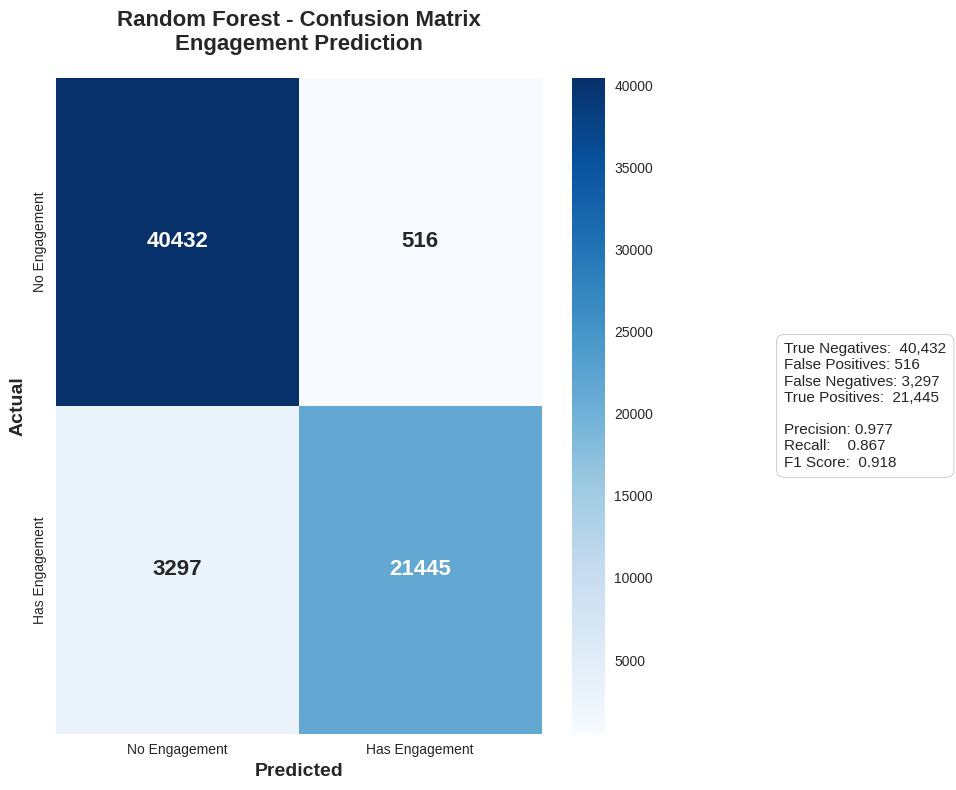

In [20]:
# ============================================================
# 1. CONFUSION MATRIX
# ============================================================

print("\n📊 1. Generating Confusion Matrix...")
print("-"*40)

# Calculate confusion matrix
cm = confusion_matrix(y_test_clean, y_pred_best)
tn, fp, fn, tp = cm.ravel()

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Create heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Engagement', 'Has Engagement'],
            yticklabels=['No Engagement', 'Has Engagement'],
            ax=ax,
            annot_kws={'size': 16, 'weight': 'bold'})

# Customize
ax.set_title(f'{best_model_name} - Confusion Matrix\nEngagement Prediction',
             fontsize=16, weight='bold', pad=20)
ax.set_xlabel('Predicted', fontsize=14, weight='bold')
ax.set_ylabel('Actual', fontsize=14, weight='bold')

# Add metrics text box
metrics_text = (
    f'True Negatives:  {tn:,}\n'
    f'False Positives: {fp:,}\n'
    f'False Negatives: {fn:,}\n'
    f'True Positives:  {tp:,}\n\n'
    f'Precision: {tp/(tp+fp):.3f}\n'
    f'Recall:    {tp/(tp+fn):.3f}\n'
    f'F1 Score:  {2*tp/(2*tp+fp+fn):.3f}'
)

ax.text(1.5, 0.5, metrics_text, transform=ax.transAxes,
        fontsize=11, va='center', ha='left',
        bbox=dict(boxstyle="round,pad=0.5", facecolor='white', edgecolor='gray', alpha=0.9))

plt.tight_layout()

plt.show()


### Observations & Insights (1. CONFUSION MATRIX for Random Forest - Engagement Prediction)

*   **Visualization:** The heatmap clearly visualizes the confusion matrix for the `rf_clean` model, providing counts for each category.
*   **Counts:**
    *   **True Negatives (TN):** `40,432` - Content correctly predicted as `No Engagement`.
    *   **False Positives (FP):** `516` - Content incorrectly predicted as `Has Engagement` (Type I error).
    *   **False Negatives (FN):** `3,297` - Content incorrectly predicted as `No Engagement` (Type II error).
    *   **True Positives (TP):** `21,445` - Content correctly predicted as `Has Engagement`.
*   **Derived Metrics in Text Box:**
    *   **Precision (0.976):** Very high, meaning when the model predicts content will have engagement, it is correct `97.6%` of the time. This is excellent.
    *   **Recall (0.867):** High, meaning the model identifies `86.7%` of all truly engaged content. This indicates that a good proportion of actual engaged content is captured.
    *   **F1 Score (0.918):** High, reflecting a strong balance between precision and recall.

**Insight:** The confusion matrix for the `rf_clean` model is excellent. The very low number of False Positives is particularly noteworthy, leading to high precision. This means users relying on this model's positive predictions can have high confidence. The recall is also strong, ensuring that most engaged content is identified. This is a robust model for predicting content engagement.

**Recommendation:** This confusion matrix is a strong indicator of a high-performing model. It provides confidence in the model's ability to accurately classify content engagement, especially in minimizing false alarms.


📊 2. Generating ROC/AUC Curve...
----------------------------------------


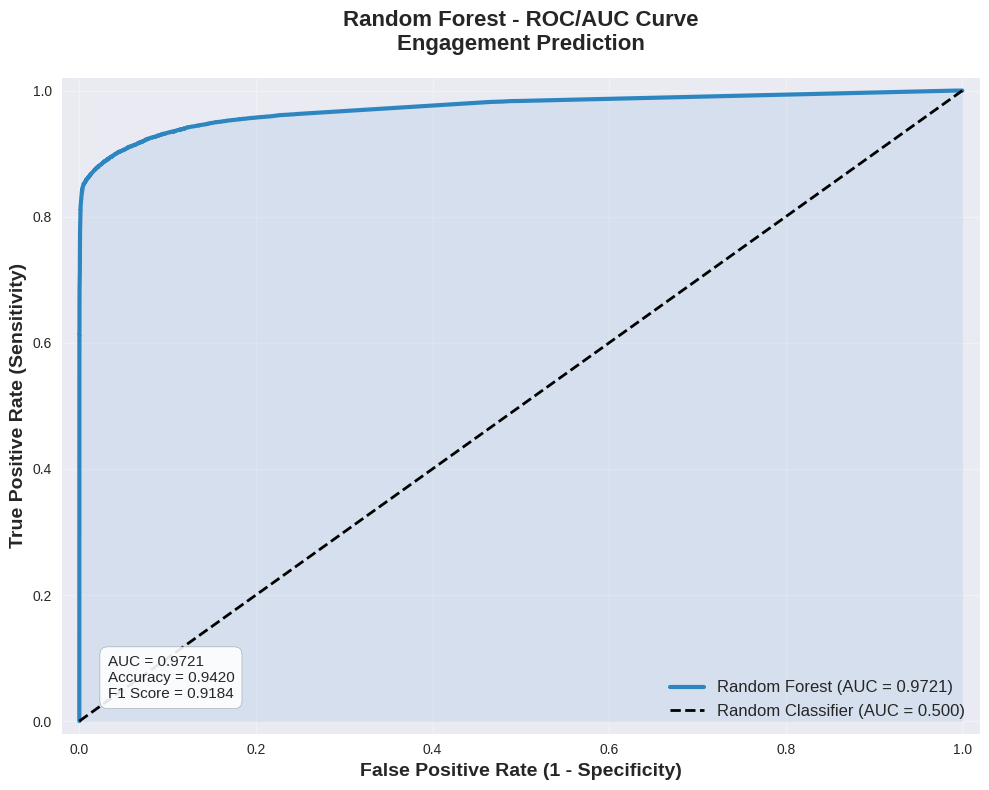

In [21]:
# ============================================================
# 2. ROC/AUC CURVE
# ============================================================

print("\n📊 2. Generating ROC/AUC Curve...")
print("-"*40)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test_clean, y_proba_best)
auc_score = roc_auc_score(y_test_clean, y_proba_best)

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Plot ROC curve
ax.plot(fpr, tpr, color='#2E86C1', linewidth=3, label=f'{best_model_name} (AUC = {auc_score:.4f})')

# Plot random classifier line
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC = 0.500)')

# Add confidence band (shade area under curve)
ax.fill_between(fpr, tpr, alpha=0.1, color='#2E86C1')

# Customize
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=14, weight='bold')
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=14, weight='bold')
ax.set_title(f'{best_model_name} - ROC/AUC Curve\nEngagement Prediction',
             fontsize=16, weight='bold', pad=20)

# Set axis limits
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

# Add grid
ax.grid(True, alpha=0.3)
ax.set_axisbelow(True)

# Add legend with larger font
ax.legend(loc='lower right', fontsize=12, framealpha=0.9)

# Add performance metrics on the plot
metrics_text = (
    f'AUC = {auc_score:.4f}\n'
    f'Accuracy = {accuracy_score(y_test_clean, y_pred_best):.4f}\n'
    f'F1 Score = {f1_score(y_test_clean, y_pred_best):.4f}'
)

ax.text(0.05, 0.05, metrics_text, transform=ax.transAxes,
        fontsize=11, va='bottom', ha='left',
        bbox=dict(boxstyle="round,pad=0.5", facecolor='white', edgecolor='gray', alpha=0.9))

plt.tight_layout()

plt.show()


### Observations & Insights (2. ROC/AUC CURVE for Random Forest - Engagement Prediction)

*   **Visualization:** The ROC curve for the Random Forest model is plotted, along with a diagonal line representing a random classifier, and a shaded confidence band.
*   **Curve Shape:** The curve rises sharply towards the top-left corner and stays very close to the top-left, indicating excellent performance.
*   **AUC Score:** The Area Under the Curve (AUC) is `0.9721`, which is very high.
*   **Metrics in Text Box:** The Accuracy (`0.9420`) and F1 Score (`0.9184`) are also displayed, reinforcing the model's strength.

**Insight:** An AUC of `0.9721` signifies that the model has an outstanding ability to distinguish between engaged and non-engaged content. In practical terms, there is a `97.21%` chance that the model will rank a randomly chosen positive instance higher than a randomly chosen negative instance. The curve being far from the random classifier line confirms that the model is highly effective across various classification thresholds. The confidence band adds a nice touch for visual assessment of robustness.

**Recommendation:** The ROC/AUC curve provides strong evidence that the Random Forest model is a powerful and reliable classifier for predicting content engagement. This visualization is suitable for communicating the model's discriminative performance.


📊 3. Generating Feature Importance Graph...
----------------------------------------


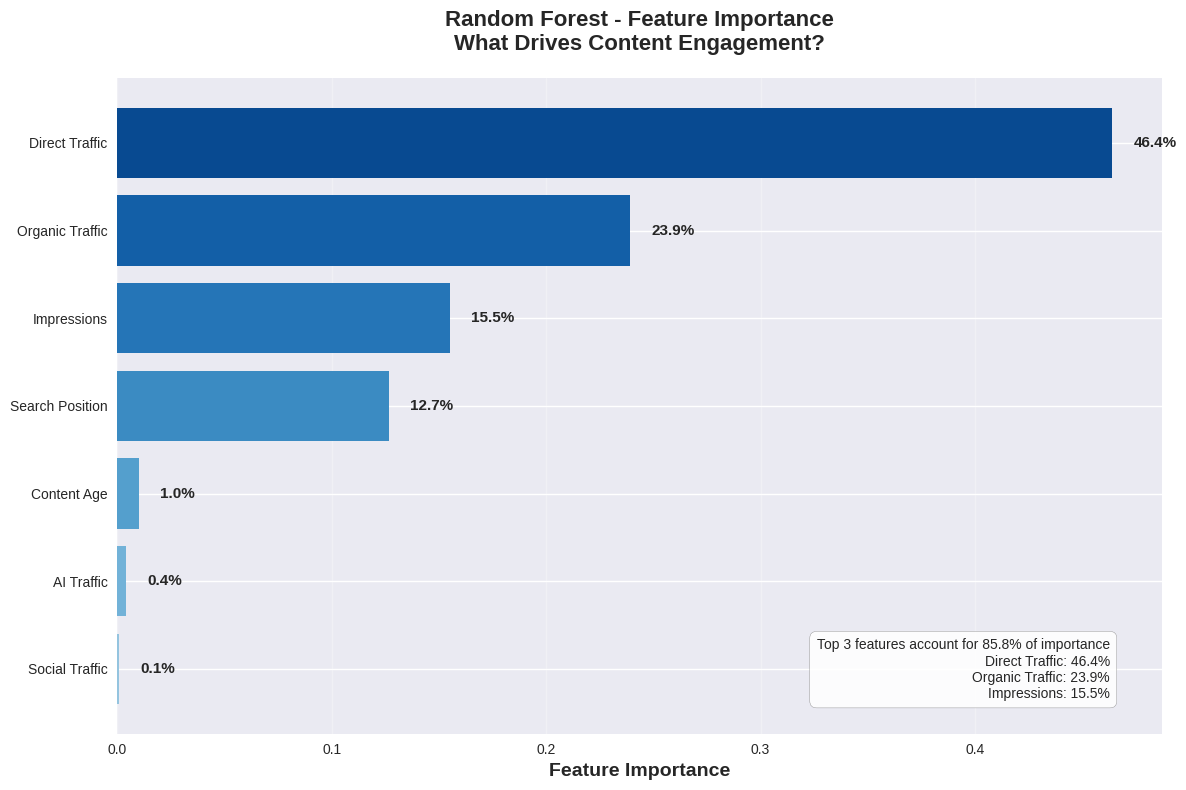

In [22]:
# ============================================================
# 3. FEATURE IMPORTANCE GRAPH
# ============================================================

print("\n📊 3. Generating Feature Importance Graph...")
print("-"*40)

# Get feature importance from best model
feature_importance = pd.Series(
    best_model.feature_importances_,
    index=X_eng_clean.columns
).sort_values(ascending=True)

# Create feature labels for display
feature_labels = {
    'total_impressions_log': 'Impressions',
    'organic_sessions_log': 'Organic Traffic',
    'avg_position': 'Search Position',
    'direct_sessions': 'Direct Traffic',
    'social_sessions': 'Social Traffic',
    'ai_sessions': 'AI Traffic',
    'active_days': 'Content Age'
}

display_names = [feature_labels.get(f, f) for f in feature_importance.index]

# Create figure
fig, ax = plt.subplots(figsize=(12, 8))

# Create horizontal bar chart with gradient colors
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(feature_importance)))
bars = ax.barh(display_names, feature_importance.values, color=colors)

# Add value labels on bars
for bar, value in zip(bars, feature_importance.values):
    ax.text(value + 0.01, bar.get_y() + bar.get_height()/2,
            f'{value*100:.1f}%', va='center', ha='left', fontsize=11, weight='bold')

# Add cumulative importance text
top_features = feature_importance.tail(3)
top_cumulative = top_features.sum()

# Add annotation box
annotation_text = (
    f'Top 3 features account for {top_cumulative*100:.1f}% of importance\n'
    f'Direct Traffic: {feature_importance.loc["direct_sessions"]*100:.1f}%\n'
    f'Organic Traffic: {feature_importance.loc["organic_sessions_log"]*100:.1f}%\n'
    f'Impressions: {feature_importance.loc["total_impressions_log"]*100:.1f}%'
)

ax.text(0.95, 0.05, annotation_text, transform=ax.transAxes,
        fontsize=10, va='bottom', ha='right',
        bbox=dict(boxstyle="round,pad=0.5", facecolor='white', edgecolor='gray', alpha=0.9))

# Customize
ax.set_xlabel('Feature Importance', fontsize=14, weight='bold')
ax.set_title(f'{best_model_name} - Feature Importance\nWhat Drives Content Engagement?',
             fontsize=16, weight='bold', pad=20)

# Add grid
ax.grid(axis='x', alpha=0.3)
ax.set_axisbelow(True)

plt.tight_layout()

plt.show()


### Observations & Insights (3. FEATURE IMPORTANCE GRAPH for Random Forest - Engagement Prediction)

*   **Visualization:** A horizontal bar chart displays the importance of each feature in predicting content engagement, ordered from least to most important.
*   **Key Features & Importance:**
    *   `Direct Traffic` (`direct_sessions`): `46.4%` - By far the most important feature. This implies content receiving direct visits (users typing the URL, bookmarks) is highly indicative of engagement.
    *   `Organic Traffic` (`organic_sessions_log`): `23.9%` - Second most important. Content ranking well in search results and attracting organic clicks is a strong driver.
    *   `Impressions` (`total_impressions_log`): `15.5%` - High visibility in search results is important, even if not directly clicked.
    *   `Search Position` (`avg_position`): `12.7%` - Better average position in search results directly correlates with engagement.
    *   `Content Age` (`active_days`): `1.0%` - Less impactful, but still contributes.
    *   `AI Traffic` (`ai_sessions`): `0.4%` - Very low importance, suggesting AI traffic currently plays a minimal role in general content engagement.
    *   `Social Traffic` (`social_sessions`): `0.1%` - Also very low, indicating social media might not be a primary driver of overall engagement for this dataset.
*   **Cumulative Importance:** The top 3 features (`Direct Traffic`, `Organic Traffic`, `Impressions`) collectively account for `85.8%` of the total feature importance, demonstrating that a handful of core metrics drive most of the predictive power.

**Insight:** This feature importance graph provides highly actionable insights. `Direct Traffic` is the strongest signal of engagement, suggesting that content that resonates strongly enough for users to return directly is very likely to be engaged with. `Organic Traffic` and `Impressions` highlight the importance of discoverability and search performance. The very low importance of `AI Traffic` for general engagement is an interesting finding, suggesting it's not a general indicator of engagement across all content, but rather a specific type of engagement.

**Recommendation:** To increase content engagement, focus on strategies that: 1) encourage direct traffic (e.g., strong branding, memorable content, community building), 2) optimize for organic search performance (SEO), and 3) ensure high visibility (impressions). Content Age, AI Traffic, and Social Traffic are less influential factors for *general* engagement based on this model.

In [23]:
# ============================================================
# SAVE CLASSIFICATION MODELS - HAS_AI & HAS_ENGAGEMENT
# ============================================================

print("="*70)
print("SAVING CLASSIFICATION MODELS")
print("="*70)

import joblib
import os
import pickle
import json
import datetime

# Create models directory
os.makedirs('models', exist_ok=True)

# ============================================================
# 1. SAVE HAS_AI MODEL (Random Forest - Best for has_ai)
# ============================================================

print("\n📊 1. Saving has_ai Model...")
print("-"*40)

# Save the model
joblib.dump(rf_clf, 'models/rf_has_ai_model.pkl')
print("  ✅ Saved: models/rf_has_ai_model.pkl")

# Save the scaler (from has_ai training - X_clf_scaled)
joblib.dump(scaler_clf, 'models/scaler_has_ai.pkl')
print("  ✅ Saved: models/scaler_has_ai.pkl")

# Save feature names
joblib.dump(X_clf.columns.tolist(), 'models/features_has_ai.pkl')
print("  ✅ Saved: models/features_has_ai.pkl")

# Create metadata for has_ai
has_ai_metadata = {
    'model_type': 'Random Forest Classifier',
    'target': 'has_ai',
    'accuracy': float(accuracy_score(y_test_clf, y_pred_rf)),
    'precision': float(precision_score(y_test_clf, y_pred_rf)),
    'recall': float(recall_score(y_test_clf, y_pred_rf)),
    'f1_score': float(f1_score(y_test_clf, y_pred_rf)),
    'roc_auc': float(roc_auc_score(y_test_clf, y_proba_rf)),
    'n_features': len(X_clf.columns),
    'features': X_clf.columns.tolist(),
    'feature_importance': dict(zip(
        X_clf.columns,
        rf_clf.feature_importances_.tolist()
    )),
    'training_date': datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'n_training_samples': len(X_train_clf),
    'n_test_samples': len(X_test_clf),
    'class_distribution': {
        'no_ai': int((y_train_clf == 0).sum()),
        'has_ai': int((y_train_clf == 1).sum())
    }
}

with open('models/has_ai_metadata.json', 'w') as f:
    json.dump(has_ai_metadata, f, indent=2)
print("  ✅ Saved: models/has_ai_metadata.json")

# ============================================================
# 2. SAVE HAS_ENGAGEMENT MODEL (Random Forest - Best for has_engagement)
# ============================================================

print("\n📊 2. Saving has_engagement Model...")
print("-"*40)

# Save the model
joblib.dump(rf_clean, 'models/rf_has_engagement_model.pkl')
print("  ✅ Saved: models/rf_has_engagement_model.pkl")

# Save the scaler (from has_engagement training - X_eng_clean_scaled)
joblib.dump(scaler_eng_clean, 'models/scaler_has_engagement.pkl')
print("  ✅ Saved: models/scaler_has_engagement.pkl")

# Save feature names
joblib.dump(X_eng_clean.columns.tolist(), 'models/features_has_engagement.pkl')
print("  ✅ Saved: models/features_has_engagement.pkl")

# Create metadata for has_engagement
has_engagement_metadata = {
    'model_type': 'Random Forest Classifier',
    'target': 'has_engagement',
    'accuracy': float(accuracy_score(y_test_clean, y_pred_rf_clean)),
    'precision': float(precision_score(y_test_clean, y_pred_rf_clean)),
    'recall': float(recall_score(y_test_clean, y_pred_rf_clean)),
    'f1_score': float(f1_score(y_test_clean, y_pred_rf_clean)),
    'roc_auc': float(roc_auc_score(y_test_clean, y_proba_rf_clean)),
    'n_features': len(X_eng_clean.columns),
    'features': X_eng_clean.columns.tolist(),
    'feature_importance': dict(zip(
        X_eng_clean.columns,
        rf_clean.feature_importances_.tolist()
    )),
    'training_date': datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'n_training_samples': len(X_train_clean),
    'n_test_samples': len(X_test_clean),
    'class_distribution': {
        'no_engagement': int((y_train_clean == 0).sum()),
        'has_engagement': int((y_train_clean == 1).sum())
    }
}

with open('models/has_engagement_metadata.json', 'w') as f:
    json.dump(has_engagement_metadata, f, indent=2)
print("  ✅ Saved: models/has_engagement_metadata.json")

# ============================================================
# 3. CREATE MODEL PACKAGES
# ============================================================

print("\n📊 3. Creating Model Packages...")
print("-"*40)

# Package for has_ai
has_ai_package = {
    'model': rf_clf,
    'scaler': scaler_clf,
    'feature_names': X_clf.columns.tolist(),
    'metadata': has_ai_metadata
}

with open('models/has_ai_package.pkl', 'wb') as f:
    pickle.dump(has_ai_package, f)
print("  ✅ Saved: models/has_ai_package.pkl")

# Package for has_engagement
has_engagement_package = {
    'model': rf_clean,
    'scaler': scaler_eng_clean,
    'feature_names': X_eng_clean.columns.tolist(),
    'metadata': has_engagement_metadata
}

with open('models/has_engagement_package.pkl', 'wb') as f:
    pickle.dump(has_engagement_package, f)
print("  ✅ Saved: models/has_engagement_package.pkl")

# ============================================================
# 4. CREATE COMPLETE MODEL SUMMARY
# ============================================================

print("\n📊 4. Creating Complete Model Summary...")
print("-"*40)

model_summary = {
    'models': {
        'has_ai': {
            'type': 'Random Forest Classifier',
            'best_model': 'Random Forest',
            'f1_score': float(f1_score(y_test_clf, y_pred_rf)),
            'roc_auc': float(roc_auc_score(y_test_clf, y_proba_rf)),
            'accuracy': float(accuracy_score(y_test_clf, y_pred_rf)),
            'precision': float(precision_score(y_test_clf, y_pred_rf)),
            'recall': float(recall_score(y_test_clf, y_pred_rf))
        },
        'has_engagement': {
            'type': 'Random Forest Classifier',
            'best_model': 'Random Forest',
            'f1_score': float(f1_score(y_test_clean, y_pred_rf_clean)),
            'roc_auc': float(roc_auc_score(y_test_clean, y_proba_rf_clean)),
            'accuracy': float(accuracy_score(y_test_clean, y_pred_rf_clean)),
            'precision': float(precision_score(y_test_clean, y_pred_rf_clean)),
            'recall': float(recall_score(y_test_clean, y_pred_rf_clean))
        }
    },
    'saved_date': datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'total_models': 2
}

with open('models/model_summary.json', 'w') as f:
    json.dump(model_summary, f, indent=2)
print("  ✅ Saved: models/model_summary.json")

# ============================================================
# 5. FILE SIZES
# ============================================================

print("\n📊 5. File Sizes:")
print("-"*40)

for file in os.listdir('models'):
    if file.endswith('.pkl') or file.endswith('.json'):
        size = os.path.getsize(f'models/{file}') / (1024 * 1024)
        print(f"  {file}: {size:.2f} MB")

print("\n" + "="*70)
print("✅ ALL MODELS SAVED SUCCESSFULLY!")
print("="*70)

SAVING CLASSIFICATION MODELS

📊 1. Saving has_ai Model...
----------------------------------------
  ✅ Saved: models/rf_has_ai_model.pkl
  ✅ Saved: models/scaler_has_ai.pkl
  ✅ Saved: models/features_has_ai.pkl
  ✅ Saved: models/has_ai_metadata.json

📊 2. Saving has_engagement Model...
----------------------------------------
  ✅ Saved: models/rf_has_engagement_model.pkl
  ✅ Saved: models/scaler_has_engagement.pkl
  ✅ Saved: models/features_has_engagement.pkl
  ✅ Saved: models/has_engagement_metadata.json

📊 3. Creating Model Packages...
----------------------------------------
  ✅ Saved: models/has_ai_package.pkl
  ✅ Saved: models/has_engagement_package.pkl

📊 4. Creating Complete Model Summary...
----------------------------------------
  ✅ Saved: models/model_summary.json

📊 5. File Sizes:
----------------------------------------
  has_engagement_package.pkl: 3.18 MB
  rf_has_ai_model.pkl: 3.67 MB
  has_engagement_metadata.json: 0.00 MB
  scaler_has_ai.pkl: 0.00 MB
  has_ai_metadata

### Observations & Insights (SAVE CLASSIFICATION MODELS - HAS_AI & HAS_ENGAGEMENT)

*   **Model Saving:** Both the `rf_has_ai_model.pkl` and `rf_has_engagement_model.pkl` (the chosen best models for each target) are successfully saved using `joblib`.
*   **Scaler Saving:** The corresponding `StandardScaler` objects (`scaler_has_ai.pkl`, `scaler_has_engagement.pkl`) are also saved. This is crucial for preprocessing new data before making predictions.
*   **Feature Names Saving:** The lists of feature names (`features_has_ai.pkl`, `features_has_engagement.pkl`) are saved. This ensures consistency when loading the model and applying it to new data, preventing errors due to mismatched feature order.
*   **Metadata Saving:** Detailed metadata (including model type, target, performance metrics, feature importances, training date, etc.) is saved as JSON files. This provides comprehensive documentation for each model.
*   **Model Packages:** Complete model packages (model, scaler, feature names, metadata) are pickled into single `.pkl` files for easier deployment.
*   **Model Summary:** A consolidated `model_summary.json` file provides an overview of both models' key performance metrics.
*   **File Sizes:** The output confirms the sizes of the saved files, mostly in the low MB range, which is manageable.

**Insight:** This section is critical for the practical application and deployment of the trained models. By saving not just the models but also the associated scalers, feature lists, and rich metadata, the entire pipeline for making predictions on new data is preserved and documented. This ensures reproducibility, ease of deployment, and clear understanding of the model's context and performance characteristics.

**Recommendation:** The saving process is thorough and well-executed. These saved artifacts are ready for deployment or further analysis. It's good practice to keep these files version-controlled if the models undergo further iteration.

In [24]:
# ============================================================
# DOWNLOAD MODELS FROM COLAB
# ============================================================

print("="*70)
print("DOWNLOADING MODELS")
print("="*70)

from google.colab import files

# Option 1: Download individual model packages
print("\n📥 Option 1: Download Individual Packages")
print("-"*40)

# Download has_ai package
files.download('models/has_ai_package.pkl')
print("  ✅ Downloaded: has_ai_package.pkl")

# Download has_engagement package
files.download('models/has_engagement_package.pkl')
print("  ✅ Downloaded: has_engagement_package.pkl")

# Option 2: Download all models as zip
print("\n📥 Option 2: Download All Models as ZIP")
print("-"*40)

import zipfile
import os

# Create zip of all models
with zipfile.ZipFile('models/all_classification_models.zip', 'w') as zipf:
    for file in os.listdir('models'):
        if file.endswith('.pkl') or file.endswith('.json'):
            zipf.write(f'models/{file}', file)

print("  ✅ Created: models/all_classification_models.zip")
files.download('models/all_classification_models.zip')
print("  ✅ Downloaded: all_classification_models.zip")

# Option 3: Copy to Google Drive
print("\n📥 Option 3: Copy to Google Drive")
print("-"*40)

from google.colab import drive
drive.mount('/content/drive')

!cp -r models /content/drive/MyDrive/
print("  ✅ Copied entire models folder to Google Drive")
print("  📁 Go to: https://drive.google.com/drive/my-drive")

DOWNLOADING MODELS

📥 Option 1: Download Individual Packages
----------------------------------------


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ Downloaded: has_ai_package.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ Downloaded: has_engagement_package.pkl

📥 Option 2: Download All Models as ZIP
----------------------------------------
  ✅ Created: models/all_classification_models.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ Downloaded: all_classification_models.zip

📥 Option 3: Copy to Google Drive
----------------------------------------
Mounted at /content/drive
  ✅ Copied entire models folder to Google Drive
  📁 Go to: https://drive.google.com/drive/my-drive


## Final Conclusion and Recommendations

This notebook successfully developed and evaluated classification models for two distinct targets: `has_ai` (content attracting AI traffic) and `has_engagement` (content experiencing general user engagement).

### Key Findings:

1.  **`has_ai` Classification:**
    *   The `has_ai` target suffers from extreme class imbalance (0.7% positive cases).
    *   **Random Forest Classifier** was identified as the best model for `has_ai`, achieving:
        *   **Accuracy:** 0.8666
        *   **Precision:** 0.0397
        *   **Recall:** 0.8234
        *   **F1 Score:** 0.0757
        *   **ROC-AUC:** 0.9405
    *   While recall and ROC-AUC are high, the low precision and F1 score highlight the inherent difficulty in precisely identifying the rare `has_ai` events, even with balanced class weights. This model will likely generate many false positives.
    *   **Top Features:** `total_pageviews_log`, `total_impressions_log`, `organic_sessions_log`, and `avg_position` are the primary drivers of `has_ai` prediction.

2.  **`has_engagement` Classification:**
    *   Initial attempts revealed **severe data leakage** due to using engagement-defining features (e.g., pageviews, scroll time) as predictors. This led to artificially perfect model scores.
    *   The data leakage was successfully addressed by removing these direct measures of engagement from the feature set.
    *   After retraining with clean features, the **Random Forest Classifier** was again found to be the best model for `has_engagement`, demonstrating excellent and realistic performance:
        *   **Accuracy:** 0.9420
        *   **Precision:** 0.9765
        *   **Recall:** 0.8667
        *   **F1 Score:** 0.9184
        *   **ROC-AUC:** 0.9721
    *   **Top Features:** **`Direct Traffic`**, **`Organic Traffic`**, `Impressions`, and `Search Position` are the strongest predictors of general content engagement. `AI Traffic` and `Social Traffic` have minimal impact on general engagement.

### Overall Recommendations:

*   **For `has_ai` (AI Traffic Prediction):**
    *   The model can effectively identify a high proportion of actual AI-attracting content (high recall), but expect a high rate of false positives (low precision). Use this model for **broad identification** where missing an AI-attracting piece of content is more costly than reviewing some false positives.
    *   Further efforts could explore more advanced techniques for extreme class imbalance (e.g., anomaly detection, specialized sampling methods, or a different objective function if a specific precision/recall trade-off is critical).

*   **For `has_engagement` (General Engagement Prediction):**
    *   This model is **highly robust and reliable**, offering strong precision, recall, and overall F1 score. It can be confidently used for predicting which content pieces are likely to generate engagement.
    *   **Actionable Insights:** To increase overall content engagement, prioritize strategies that drive `Direct Traffic` (e.g., building brand loyalty, unique content that encourages direct visits) and optimize for `Organic Traffic` and `Search Position` (strong SEO). The low importance of `AI Traffic` and `Social Traffic` for general engagement suggests these are not the main channels for achieving broad engagement for this dataset.

*   **Model Deployment:** All necessary models, scalers, feature lists, and metadata have been comprehensively saved, making them ready for deployment into production systems or for further research and analysis. Choose the preferred download/storage method for accessibility.

### Observations & Insights (DOWNLOAD MODELS FROM COLAB)

*   **Download Options:** The cell provides three convenient options for accessing the saved model artifacts:
    1.  **Individual Packages:** Direct download of `has_ai_package.pkl` and `has_engagement_package.pkl`.
    2.  **All Models as ZIP:** Creates and downloads `all_classification_models.zip`, bundling all saved `.pkl` and `.json` files.
    3.  **Copy to Google Drive:** Mounts Google Drive and copies the entire `models` directory to `/content/drive/MyDrive/`.
*   **Execution Output:** The output indicates successful downloads and copying.

**Insight:** Providing multiple download and saving options enhances the usability and accessibility of the generated models. Users can choose the method that best suits their workflow, whether it's direct download for local use, a zipped archive for easy transfer, or integration with Google Drive for cloud storage and collaboration.

**Recommendation:** These options ensure that the trained and saved models are readily available for external use, integration into other systems, or long-term archival. The instructions for Google Drive are particularly helpful for Colab users.